## **1. Préliminaires**

### **1.1. Contexte**
Nous pratiquons dans ce notebook l'analyse de données sur les données provenant d'un dataset `heart attack prediction` de [Kaggle](https://kaggle.com/datasets).
Nous allons dans ce notebook explorer , visualiser et interpreter nos variables.

### **1.2. Imports des librairies**

Dans cette section nous allons importer les librairies principales .

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **1.3. Chargement des données**
Nous allons maintenant charger notre dataset .

In [2]:
# chargement du dataset
data = pd.read_csv('../data/data-cleaned.csv')

# affichage d'un extrait
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0


### **1.4. Structure et typologie des données**
Nous allons analyser la structure de notre jeu de données et le types des données et changer les types de données si nécessaires.

In [3]:
# dimension du dataset
data.shape

(284, 11)

In [4]:
# affichage des infos sur les variables et leurs types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       284 non-null    int64  
 1   sex       284 non-null    int64  
 2   cp        284 non-null    int64  
 3   trestbps  284 non-null    float64
 4   chol      284 non-null    float64
 5   fbs       284 non-null    float64
 6   restecg   284 non-null    float64
 7   thalach   284 non-null    float64
 8   exang     284 non-null    float64
 9   oldpeak   284 non-null    float64
 10  num       284 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 24.5 KB


## **2. Analyse Exploratoire des données**

### **2.1. Analyse univariée**

Nous allons observer la distribution de chaque variable.
Nous allons pour certains graphiques utiliser des diagramme à baton et pour d'autres des diagrammes circulaires.

##### **2.1.1. Fonctions pour les graphiques**
Nous allons créer quelques fonctions

In [5]:
import math

# fonction retournant des pie charts

def show_pie_charts(params: dict):
    nrows = math.ceil(len(params) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2,figsize=(25,35))
    axes_plats = axes.flatten()
    for i, (col, param) in enumerate(params.items()):
        value = param["value"]
        axes_plats[i].pie(
            x=value["count"],
            labels=value[col],
            startangle=value.get('startangle',90),
            colors=value["color"],
            autopct="%.2f%%",
        )
        axes_plats[i].legend()
        axes_plats[i].set_title(f"Repartition des partiens par {col}")
        # axes_plats[i].margins(y=0.2)

    # pour supprimer les graphiques vides
    if len(params)<len(axes_plats):
        for j in range(len(params),len(axes_plats)):
            axes_plats[j].set_axis_off()

In [6]:
# fonction retournant des bar charts

def show_bar_charts(params: dict):
    nrows = math.ceil(len(params) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(30, 20))
    axes_plats = axes.flatten()
    for i, (col, param) in enumerate(params.items()):
        ax=axes_plats[i]
        sns.barplot(ax=ax,data=param['value'],hue=col,y='count',errorbar=None,palette=param.get('palette'))
        ax.set_ylabel("nombre de patients")
        ax.set_xlabel(col)
        ax.set_title(f"Diagramme à barre de repartition par {col}")
        if param.get('yticks') is not None:
            ax.set_yticks(ticks=param.get('yticks'))
    # pour supprimer les graphiques vides
    if len(params)<len(axes_plats):
        for j in range(len(params),len(axes_plats)):
            axes_plats[j].set_axis_off()

##### **2.1.2. La variable `num`** 

In [7]:
# le compte des modalités de nums
num_counts = data["num"].value_counts().reset_index()

# les labels
num_labels = {0: "malade", 1: "sain"}
num_counts.replace({"num": num_labels}, inplace=True)

# les couleurs
num_counts["color"] = sns.color_palette(palette="viridis", n_colors=num_counts.shape[0])

num = {"value":num_counts}

##### **2.1.3. La variable `fbs`** 

In [8]:
# compte des modalités de fbs
fbs_count = data.value_counts(subset=['fbs']).reset_index()

# les labels
fbs_labels = {0: "Normal", 1: "Hyperglycémie"}
fbs_count.replace({"fbs": fbs_labels}, inplace=True)

# les couleurs
fbs_count["color"] = sns.color_palette(palette="pastel", n_colors=fbs_count.shape[0])
fbs = {"value": fbs_count}

##### **2.1.4. La variable `restecg`** 

In [9]:
# le compte des modalités de restecg
restecg_counts = data.value_counts(subset=['restecg']).reset_index()

# les labels
restecg_labels={0:'Normal',1:'Anomalie des ondes ST-T',2:'Hypertrophie ventriculaire gauche probable ou certaine'}
restecg_counts.replace({"restecg": restecg_labels}, inplace=True)

# les couleurs
restecg_counts["color"] = sns.color_palette(
    palette="husl", n_colors=restecg_counts.shape[0]
)

restecg = {"value": restecg_counts,'startangle':180}

##### **2.1.5. La variable `exang`**

In [10]:
# le compte des modalités de exang
exang_counts = data.value_counts(subset=["exang"]).reset_index()

# les labels
exang_labels = {
    0: "Normal",
    1: "Angine induite par l’exercice",
}
exang_counts.replace({"exang": exang_labels}, inplace=True)

# les couleurs
exang_counts["color"] = sns.color_palette(
    palette="magma", n_colors=exang_counts.shape[0]
)
exang = {'value':exang_counts,"startangle":360}

##### **2.1.6. La variable `age`**

In [11]:
# discretisation de la variable âge
age_bins = pd.cut(data["age"], bins=np.arange(20, 80, 10)).value_counts().reset_index()

age = {"value": age_bins, "palette": None, "yticks": np.arange(0, 140, 10)}

##### **2.1.7. La variable `cp`**

In [12]:
# le compte par modalité
cp_counts = data["cp"].value_counts().reset_index()
# labelisation
cp_labels = {
    1: "Angine typique",
    2: "Angine atypique",
    3: "Douleur non angineuse",
    4: "Asymptomatique",
}
cp_counts.replace({"cp": cp_labels}, inplace=True)
cp_yticks=np.arange(0, 140, 10)
cp = {"value": cp_counts, "yticks": cp_yticks, "palette": "plasma"}

##### **2.1.8. La variable `thalach`**

In [13]:
# discretisation de la variable
thalach_bins = (
    pd.cut(data["thalach"], bins=np.arange(80, 220, 20)).value_counts().reset_index()
)

thalach = {"value": thalach_bins,'yticks':None,'palette':'flare'}

##### **2.1.9. La variable `trestbps`**

In [14]:
# discretisation
data['trestbps'].describe()
trestbps_bins = pd.cut(data['trestbps'],bins=np.arange(90,240,30)).value_counts().reset_index()
trestbps_yticks = np.arange(0, 170, 10)
trestbps = {"value": trestbps_bins, "yticks": trestbps_yticks, "palette": "viridis"}

##### **2.1.10. La variable `sex`**

In [15]:
# compte des modalités
sex_counts = data['sex'].value_counts().reset_index()

# labels
sex_labels = {0:'Femme',1:'Homme'}
sex_counts.replace({"sex": sex_labels}, inplace=True)
sex_counts["color"] = sns.color_palette(palette="Set2", n_colors=sex_counts.shape[0])

sex = {'value':sex_counts}

##### **2.1.11. La variable `oldpeak`**

In [16]:
# compte des modalités de oldpeak
oldpeak_counts= pd.cut(data["oldpeak"],bins=np.arange(0,6,1)).value_counts().reset_index()

oldpeak = {"value": oldpeak_counts, "palette": "Spectral"}

##### **2.1.12. La variable `chol`**

In [17]:
data.chol.describe()

count    284.000000
mean     248.352113
std       62.963077
min       85.000000
25%      211.000000
50%      243.000000
75%      275.250000
max      603.000000
Name: chol, dtype: float64

In [18]:
chol_counts = pd.cut(data["chol"], bins=np.arange(0, 800, 100)).value_counts().reset_index()

chol_yticks = np.arange(0,220,20)

chol = {"value": chol_counts, "palette": "icefire", "yticks": chol_yticks}
chol_counts

,chol,count
0,"(200, 300]",192
1,"(100, 200]",52
2,"(300, 400]",32
3,"(400, 500]",3
4,"(0, 100]",2
5,"(500, 600]",2
6,"(600, 700]",1


##### **2.1.9. Graphiques**

In [19]:
pie_charts_params = {
    "restecg": restecg,
    "fbs": fbs,
    "num": num,
    "exang": exang,
    "sex": sex,
}
bar_charts_params = {
    "cp": cp,
    "thalach": thalach,
    "age": age,
    "trestbps": trestbps,
    "oldpeak": oldpeak,
    "chol": chol,
}

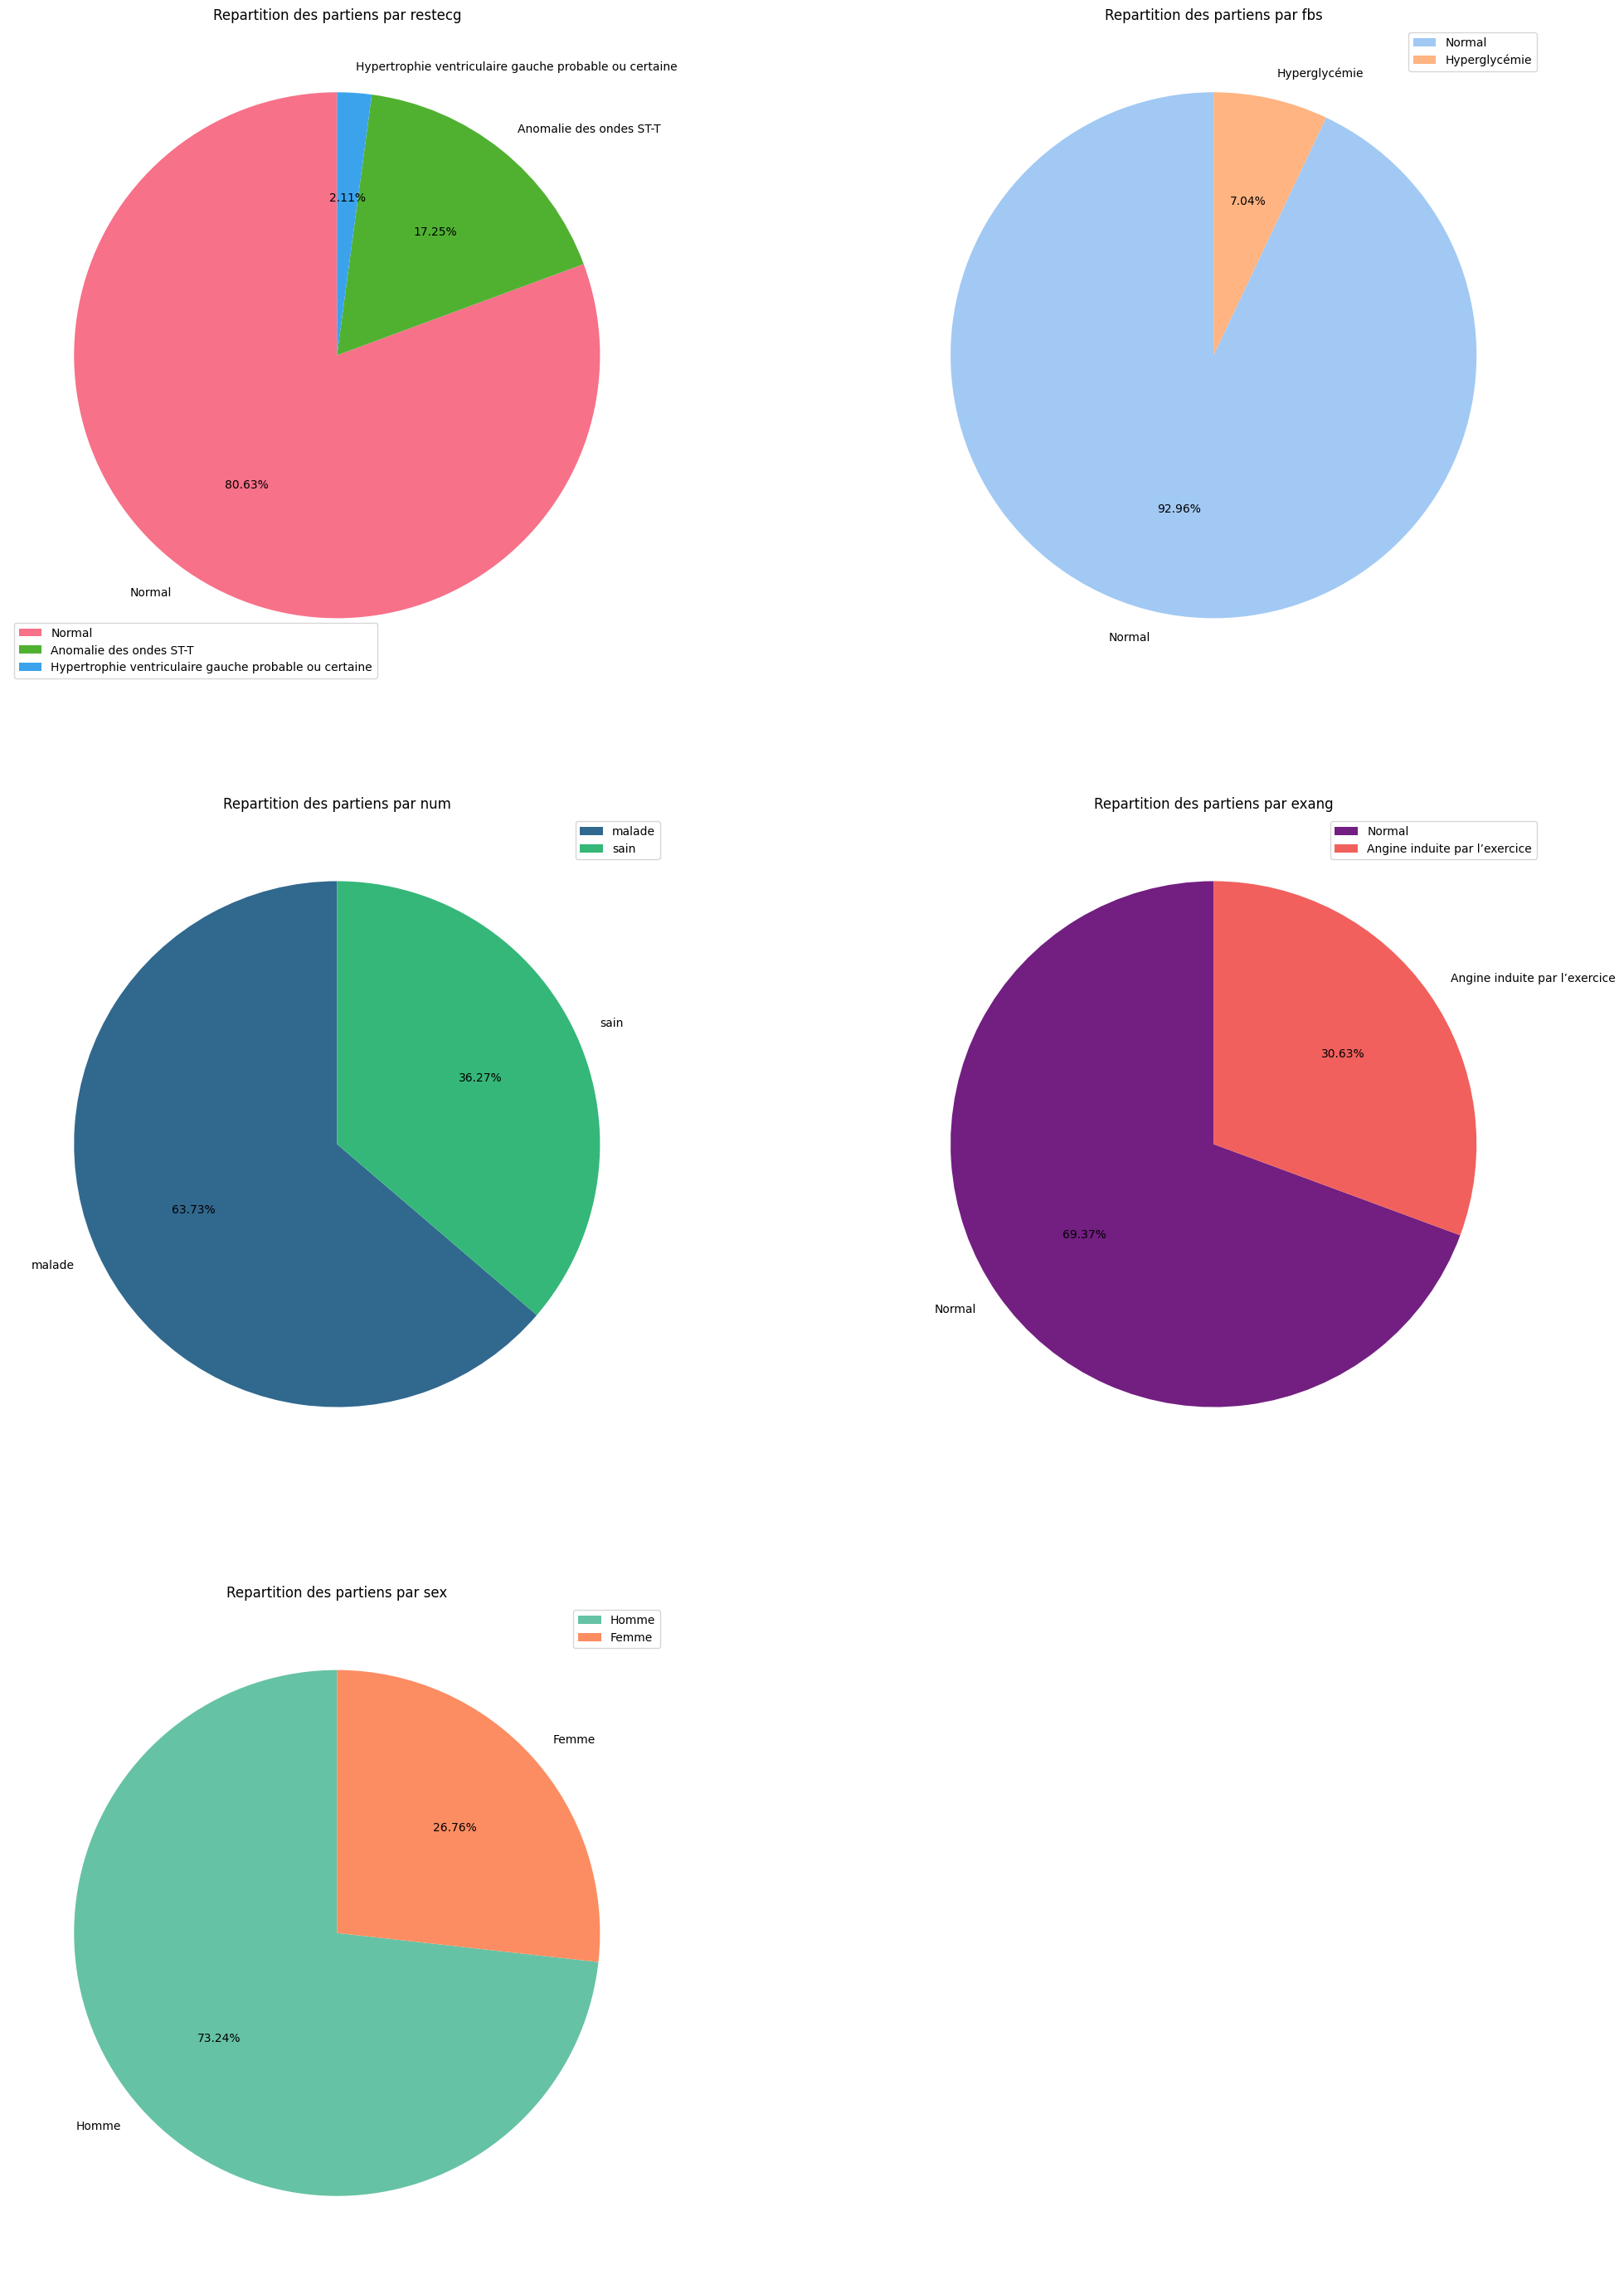

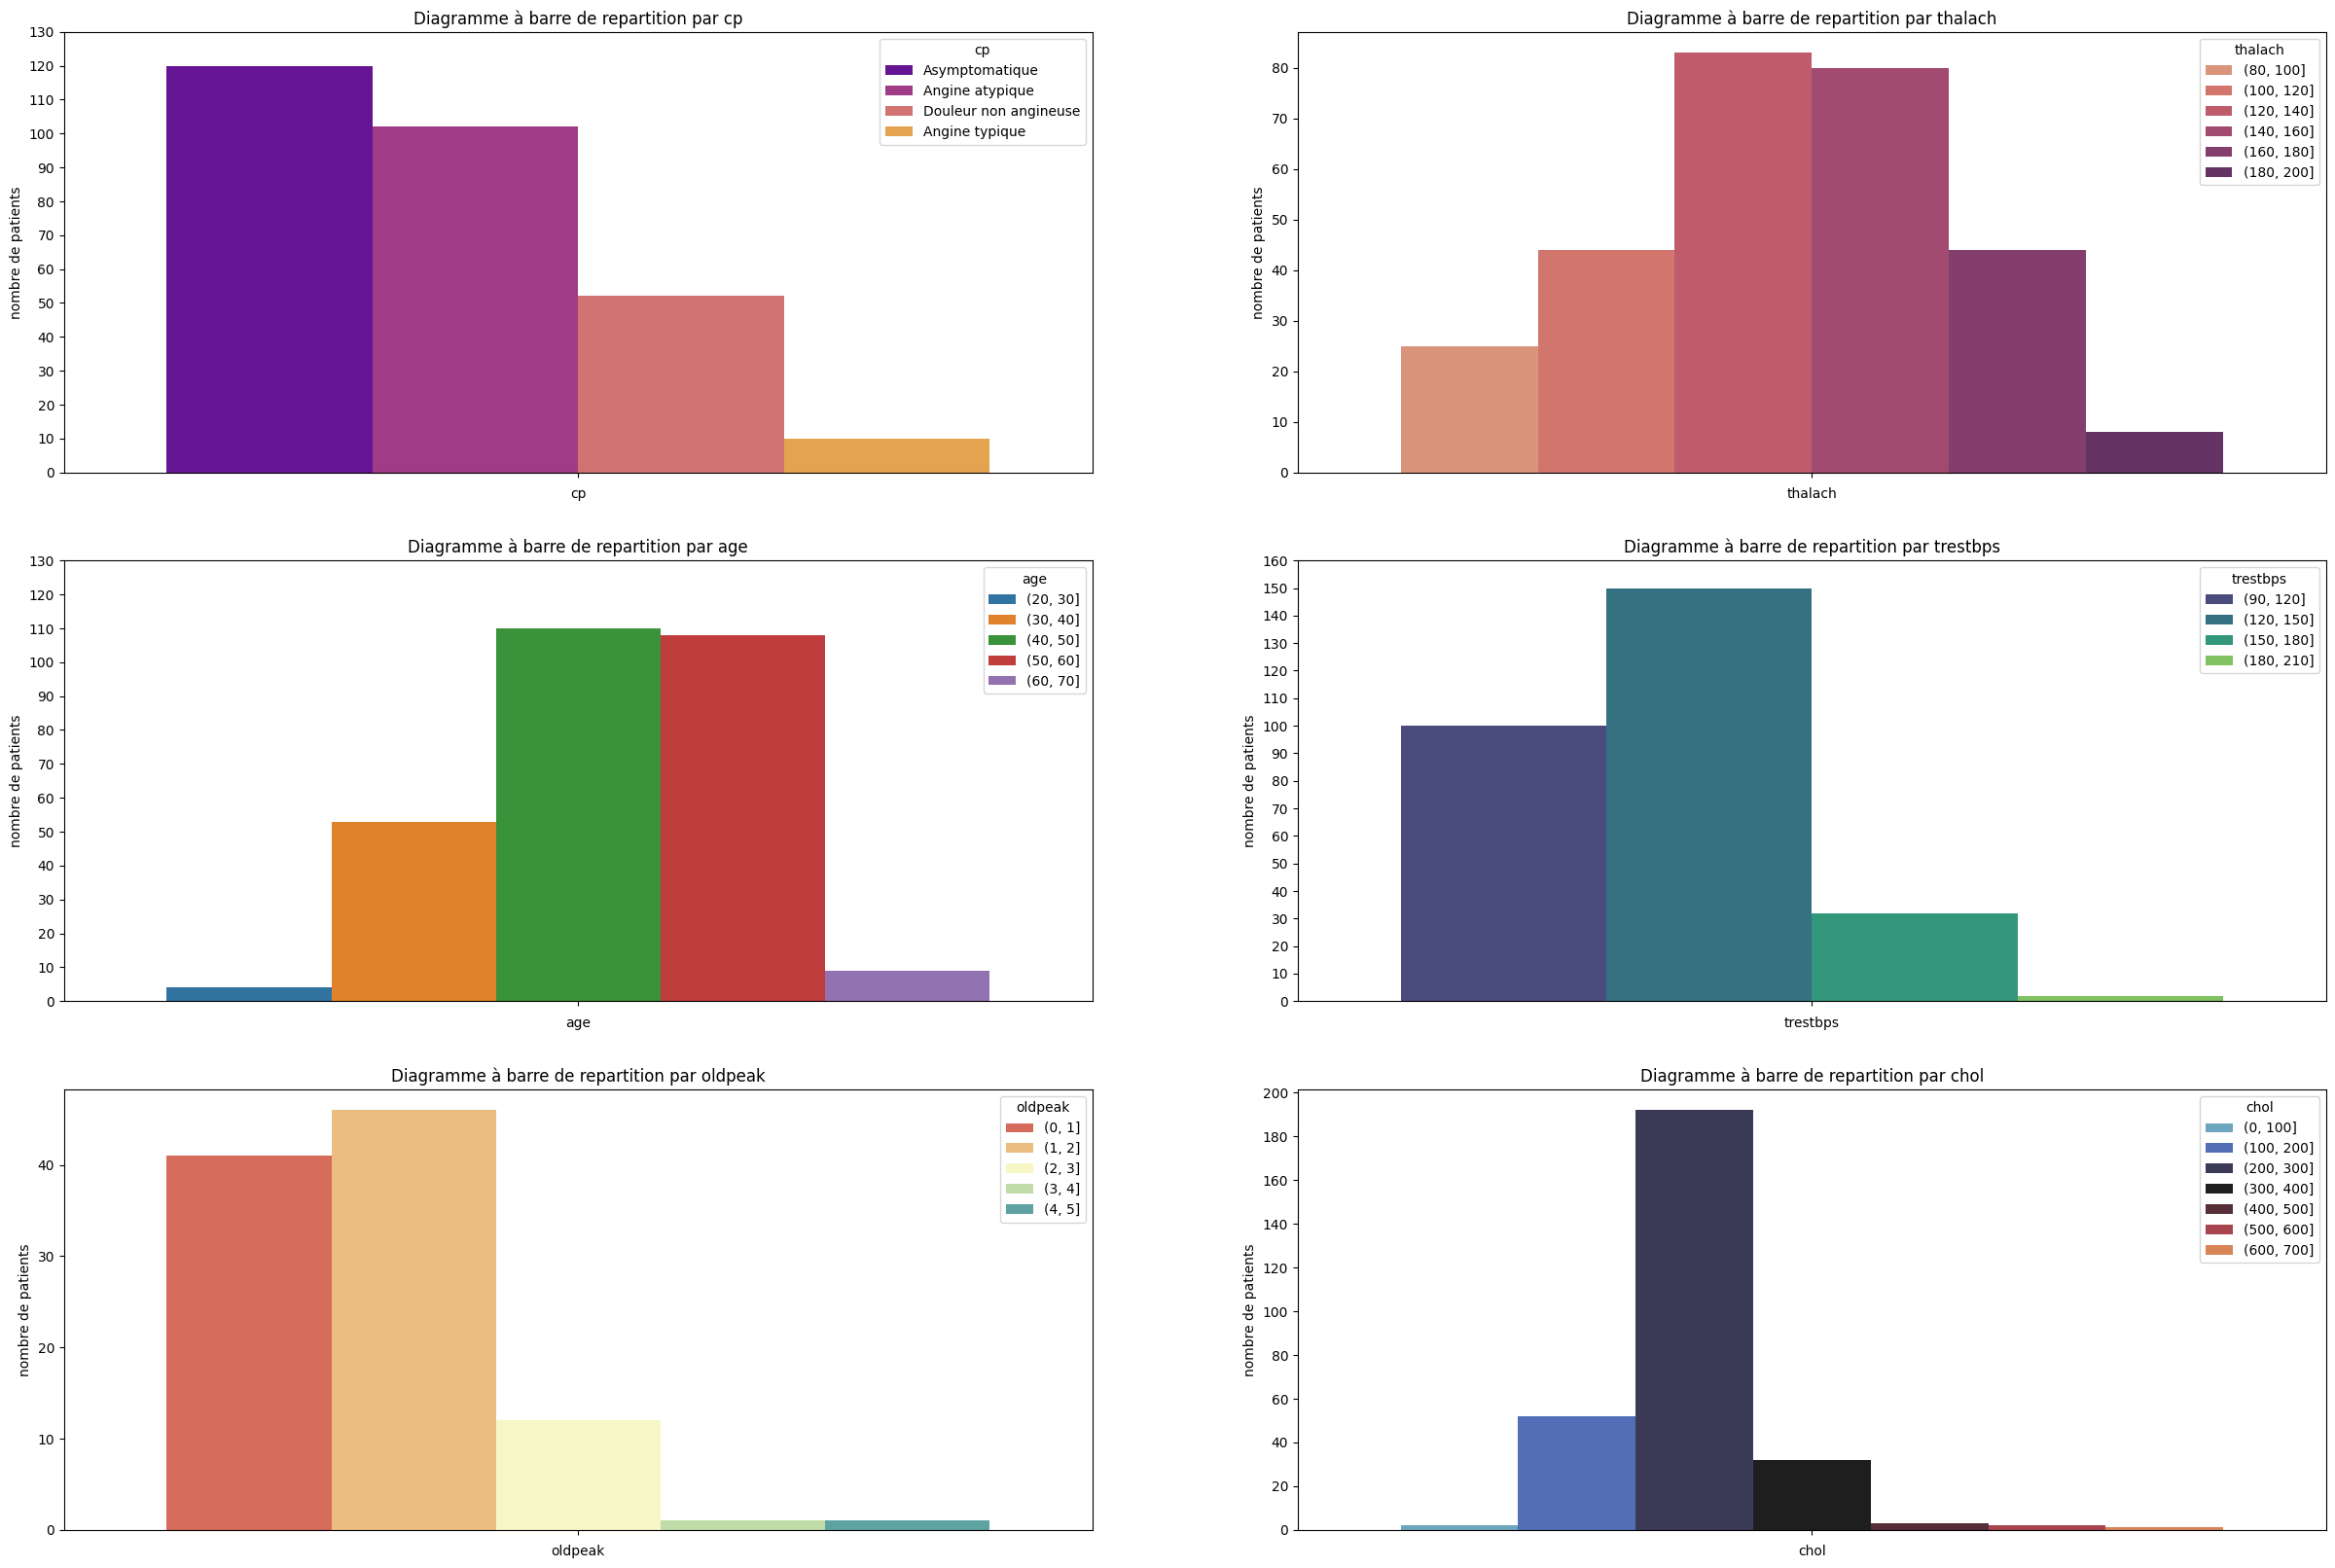

In [20]:
pie_charts = show_pie_charts(params=pie_charts_params)
bar_charts = show_bar_charts(params=bar_charts_params)
plt.show()

**interpretation**  : 

La majorité des patients est de sexe masculin et se trouve entre 40 et 60 ans.
Plus de la moitié des patients est malade  , avec une minorité (7.04%) qui présentent une hyperglycémie et une partie (17.25%) semble présenter des anomalies des ondes ST-T.
On remarque plusieurs cas majoritaire de douleur thoraxique **asymptomatique** et minoritaires pour **Anginge typique**.
La majorité des patients ont un taux de cholesterole entre [200,300] et certains ont un taux très éleves de cholesteroles entre 400 et 600.
**30.63%** des patients ont des douleurs après exercise.
On a une minorité de patients qui a une frequence cardiaque maximale entre 80 et 100.

On a un certain nombre de patients avec une pression artérielle au repos entre 150 et 210 qui pourrait être à risque.

On a une minorité de patient qui semble présenter un stress cardiaque et une partie bien que minoritaire semble présenter un taux de cholesterole superieur à 400

### **2.2. Analyse Multivariée**

 Matrice des corrélations

In [21]:
# tableau des corrélations
tab_corr = data.corr()
tab_corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
age,1.000000,0.023669,0.164283,0.243916,0.092117,0.183430,0.038061,-0.469983,0.259535,0.188361,0.171262
sex,0.023669,1.000000,0.235716,0.084390,0.053751,0.042032,-0.080983,-0.112049,0.142891,0.117198,0.257470
cp,0.164283,0.235716,1.000000,0.093759,0.156653,0.030675,-0.004554,-0.384275,0.490002,0.352821,0.516433
trestbps,0.243916,0.084390,0.093759,1.000000,0.111266,0.095853,0.007677,-0.185939,0.223977,0.212688,0.144280
chol,0.092117,0.053751,0.156653,0.111266,1.000000,0.122389,0.057886,-0.130019,0.169459,0.112901,0.212628
fbs,0.183430,0.042032,0.030675,0.095853,0.122389,1.000000,0.051070,-0.071630,0.115633,0.063504,0.164492
restecg,0.038061,-0.080983,-0.004554,0.007677,0.057886,0.051070,1.000000,-0.004772,0.055110,0.040810,-0.017913
thalach,-0.469983,-0.112049,-0.384275,-0.185939,-0.130019,-0.071630,-0.004772,1.000000,-0.414947,-0.308685,-0.342803
exang,0.259535,0.142891,0.490002,0.223977,0.169459,0.115633,0.055110,-0.414947,1.000000,0.631273,0.579071
oldpeak,0.188361,0.117198,0.352821,0.212688,0.112901,0.063504,0.040810,-0.308685,0.631273,1.000000,0.555399


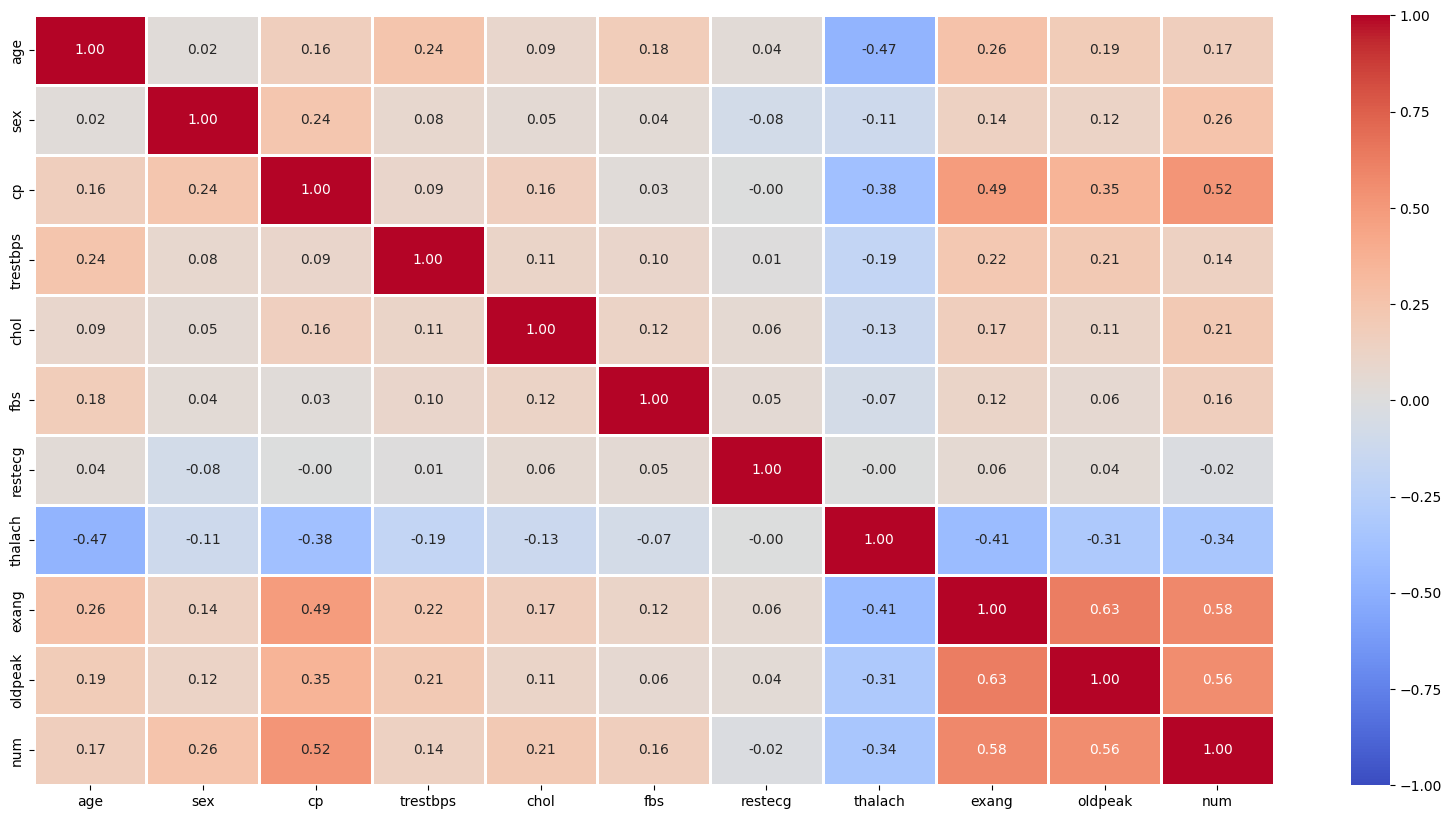

In [22]:
# matrice des corrélations

plt.figure(figsize=(20,10))
sns.heatmap(vmin=-1,vmax=1,data=tab_corr,cmap="coolwarm",annot=True,fmt=".2f",linewidths=1.0)

plt.show()

Interprétation
On remarque que notre variable cible `num` est fortement corrélée avec `oldpeak` ,`exang` et `cp`.

`exang` est également fortement corrélée avec `oldpeak` et modérement avec `cp`

`oldpeak` est modérement corrélée avec `cp`.

### **2.3** Analyse par composante principales

#### **2.3.1** Preparation des données

In [23]:
numerical_cols = ["age", "trestbps", "chol", "thalach","oldpeak"]
X = data[numerical_cols].copy()

#### **2.3.2** Standarisation
Nous allons normaliser les données

In [24]:
from sklearn.preprocessing import StandardScaler

# initialisation du scaler
scaler = StandardScaler()

# matrice centrée et réduite
X_Scaled = scaler.fit_transform(X)

# verification
pd.DataFrame(X_Scaled).describe().round(2).loc[['std','mean']]

,0,1,2,3,4
std,1.0,1.0,1.0,1.0,1.0
mean,0.0,-0.0,-0.0,0.0,-0.0


#### **2.3.3** ACP

In [25]:
from sklearn.decomposition import PCA

# nombre de composantes
n_components  = 5

# instanciation du PCA
pca = PCA(n_components=n_components)

# on entraine notre PCA
pca.fit(X_Scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

#### **2.3.4** Variance expliquée et scree plot

In [26]:
for i , v in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1} : {v:.2%} de variance expliquée")

PC1 : 37.58% de variance expliquée
PC2 : 19.12% de variance expliquée
PC3 : 17.11% de variance expliquée
PC4 : 16.21% de variance expliquée
PC5 : 9.97% de variance expliquée


In [27]:
# enregistrons les variances expliquées
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([37.58, 19.12, 17.11, 16.21,  9.97])

In [28]:
# variances expliquées cumulées
scree_cum = np.cumsum(scree).round()
scree_cum

array([ 38.,  57.,  74.,  90., 100.])

In [29]:
# labels des composantes
components_labels = [str(i+1) for i in range(n_components)]
components_labels

['1', '2', '3', '4', '5']

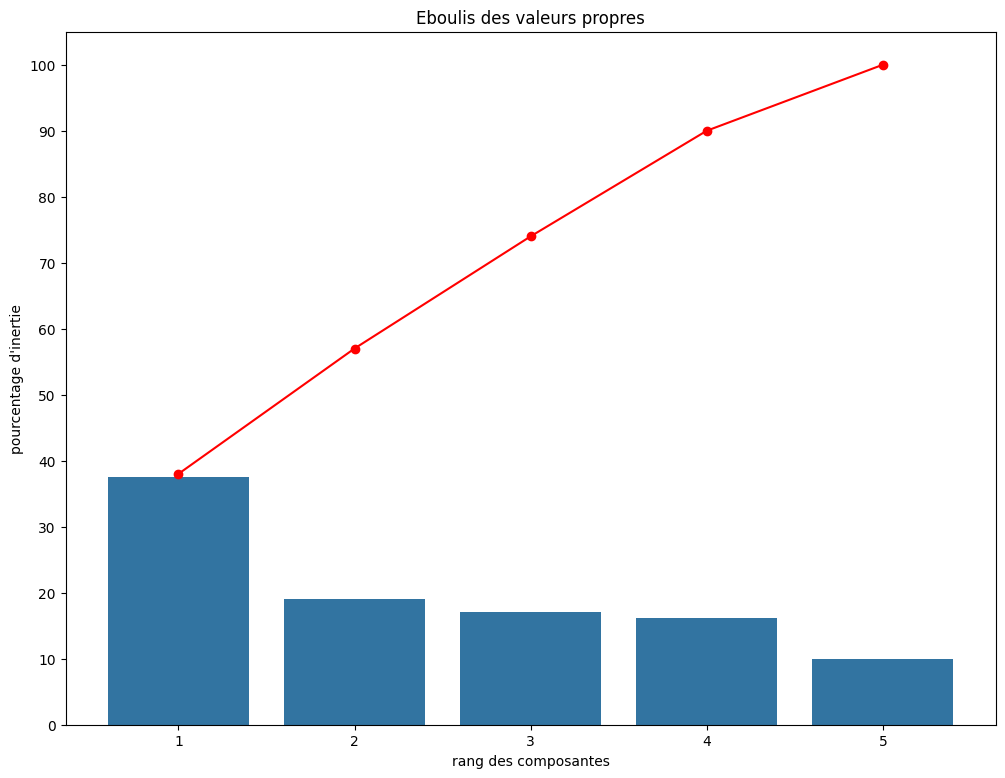

In [30]:
# graphique de l'eboulis des valeurs propres

plt.figure(figsize=(12,9))

sns.barplot(x=components_labels,y=scree,errorbar=None)

plt.plot(components_labels,scree_cum, c="red",marker="o")

plt.yticks(ticks=np.arange(0,110,10))

plt.xlabel("rang des composantes")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")

plt.show()

#### **2.3.5** `Les composantes`

In [31]:
# transformation de la matrice des composantes en dataframe
pcs = pd.DataFrame(pca.components_)
pcs.head()

,0,1,2,3,4
0,-0.528009,-0.400864,-0.244488,0.556619,-0.436939
1,-0.309533,0.107978,0.915318,0.227832,0.053057
2,-0.322255,0.743061,-0.307023,0.363665,0.342779
3,-0.337736,-0.497507,-0.078133,-0.093070,0.789718
4,0.638343,-0.167321,0.045276,0.705233,0.255182


In [32]:
pcs.columns = X.columns
pcs.index = [f"F{i}" for i in components_labels]
pcs.head()

,age,trestbps,chol,thalach,oldpeak
F1,-0.528009,-0.400864,-0.244488,0.556619,-0.436939
F2,-0.309533,0.107978,0.915318,0.227832,0.053057
F3,-0.322255,0.743061,-0.307023,0.363665,0.342779
F4,-0.337736,-0.497507,-0.078133,-0.093070,0.789718
F5,0.638343,-0.167321,0.045276,0.705233,0.255182


#### **2.3.6** `Matrice des corrélations`

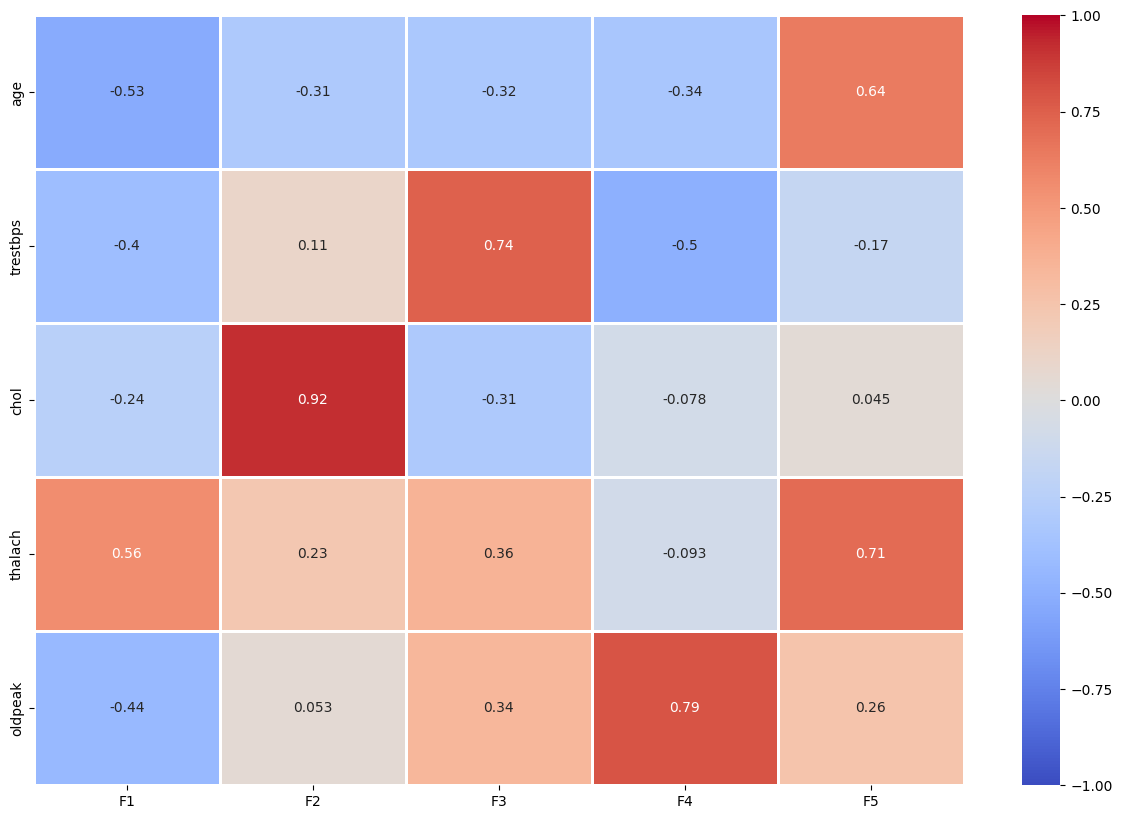

In [33]:
# matrice de corrélation

plt.figure(figsize=(15,10))

sns.heatmap(vmin=-1,vmax=1,annot=True,linewidths=2,data=pcs.T,cmap="coolwarm")
plt.show()

Interprétation

F1 est très corrélé à thalach 
F2 est très corrélé à chol
F3 est très corrélé à threstbps
F4 est très corrélé à olpeak
F5 est très corrélé à age et thalach

#### **2.3.7** `Graphe des corrélations`

In [53]:
def correlation_graph(x_y,pca:PCA,features:list):
    # initialisation des axes
    x,y=x_y

    # initialisation de la figure
    fig,ax = plt.subplots(figsize=(12,9))

    # tracée des flêches
    for i in range(len(features)):
        plt.arrow(
            x=0,
            y=0,
            dx=pca.components_[x,i],
            dy=pca.components_[y,i],
            head_width=0.04,
            head_length=0.04,
        )

        plt.text(
            x=pca.components_[x,i]+0.05,
            y=pca.components_[y,i]+0.05,
            s=features[i]
            )

    # tracée des axes
    plt.plot([-1,1],[0,0],color="grey",alpha=0.8,ls="--")
    plt.plot([0, 0],[-1, 1], color="grey", alpha=0.8, ls="--")

    # nommage des axes
    v1,v2 = [f"{pca.explained_variance_ratio_[k]:.1%}" for k in x_y]
    plt.xlabel(f"F{x+1} {v1}")
    plt.ylabel(f"F{y+1} {v2}")

    # tracée du cercle
    theta = np.linspace(0,2*np.pi,100)
    plt.plot(np.cos(theta),np.sin(theta))
    plt.axis("equal")

    # titre
    plt.title(f"Cercle des corrélations (F{x+1} et F{y+1})")

    # affichage
    plt.show()

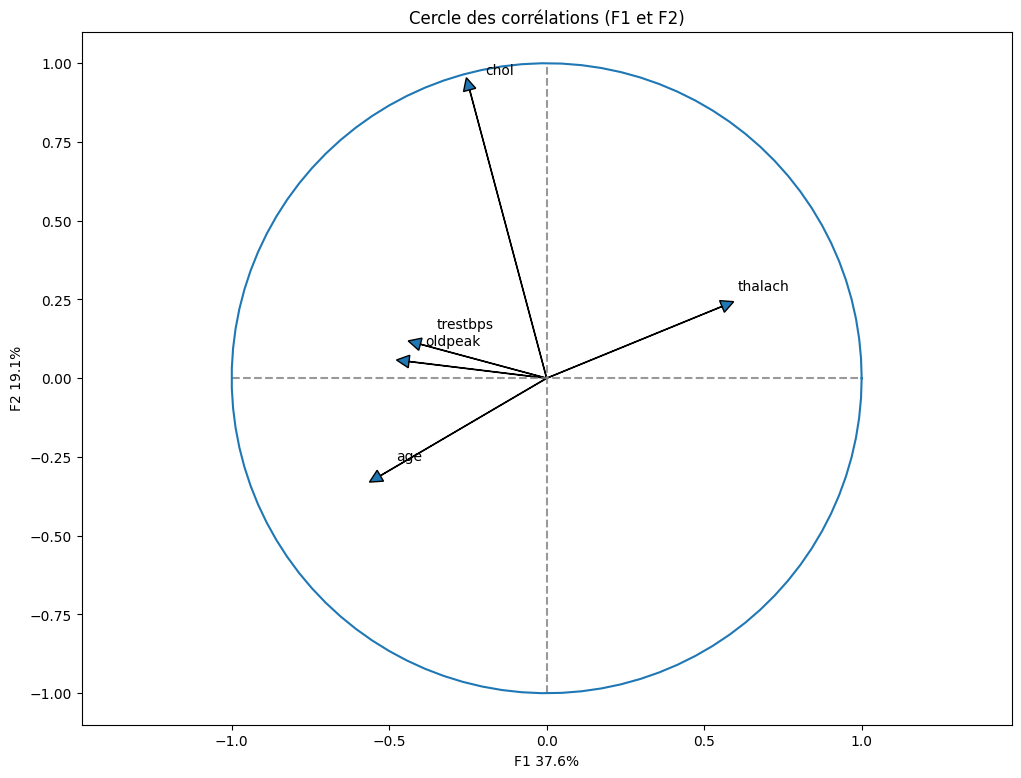

In [54]:
# graphe F1 et F2
x_y = 0,1
correlation_graph(x_y=x_y, pca=pca, features=numerical_cols)

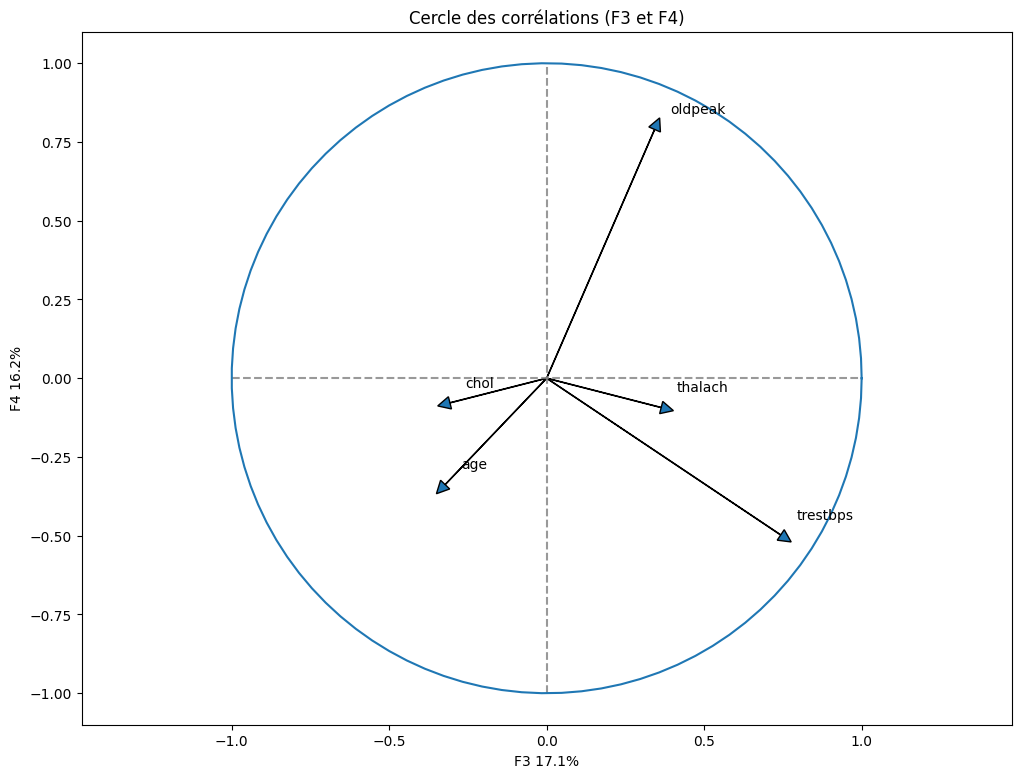

In [55]:
# graphe F3 et F4
x_y = 2, 3
correlation_graph(x_y=x_y, pca=pca, features=numerical_cols)

## **3.** `Clustering`

### **3.1** `Initialisation du KMeans`

Nous allons initialiser un k-means pour différentes valeurs de k et enregistrer les inerties afin de réaliser le diagramme de l'inertie en fonction du nombre de clusters et choisir celui qui convient le mieux .

In [66]:
# import de KMeans
from sklearn.cluster import KMeans

In [74]:
# les k potentiels
k_list = [i for i in range(1,11)]

# liste qui contiendra les inerties
inertia_list = []

In [75]:
for k in k_list:
    # initialisation du KMeans
    kmeans = KMeans(n_clusters=k)

    # entrainement
    kmeans.fit(X_Scaled)

    # enregistrement de l'inertie
    inertia_list.append(kmeans.inertia_)


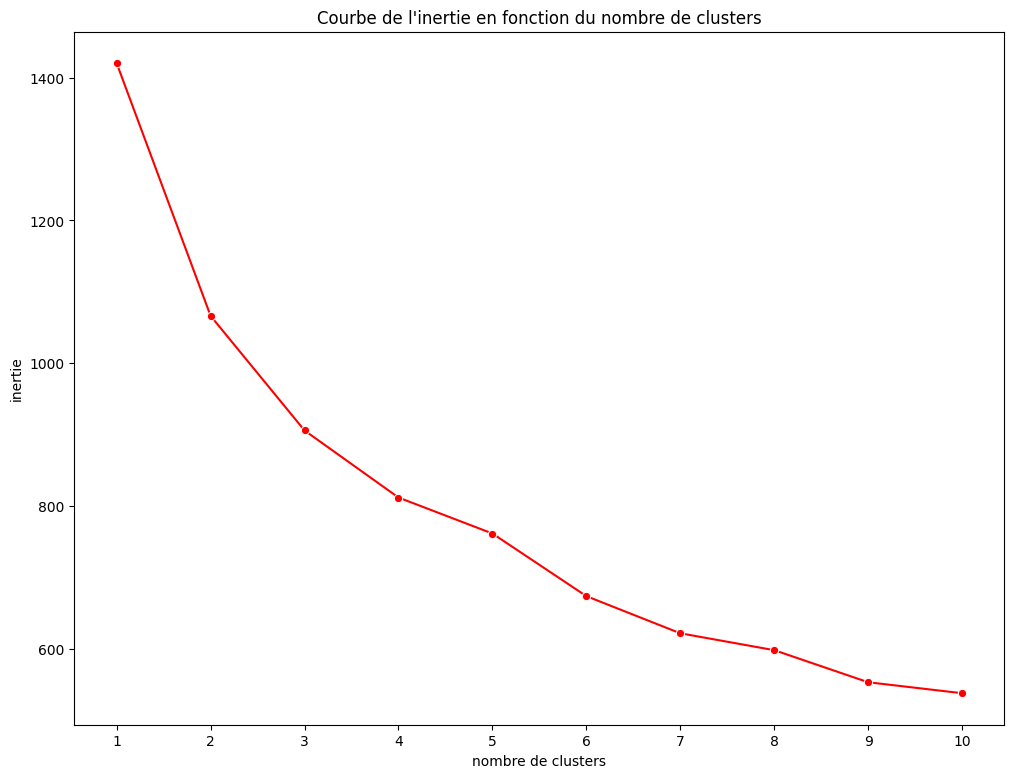

In [77]:
# liste des labels des k
k_labels = [str(i) for i in k_list]

# initialisation de la figure
plt.figure(figsize=(12,9))

# courbe
sns.lineplot(x=k_labels,y=inertia_list,c="red",marker="o")

# titre et labels des axes
plt.xlabel("nombre de clusters")
plt.ylabel("inertie")
plt.title("Courbe de l'inertie en fonction du nombre de clusters")

# affichage
plt.show()

Nous allons choisir 3 comme nombre de clusters 

### **3.2** `Projection sur les plans factoriels`

In [108]:
# initialisation de notre KMeans final
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X_Scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [109]:
# clusters
clusters = kmeans.labels_

# matrice des points projetés
X_Projected = pca.transform(X_Scaled)

In [110]:
def display_factorial_planes(
    x_y,
    X_projected,
    pca=None,
    palette="plasma",
    labels=None,
    figsize=(12, 9),
    clusters=None,
    alpha=1,
):

    # transformation en array numpy
    X_ = np.array(X_projected)

    # verification des input
    labels = [] if labels is None else labels

    if not len(x_y) == 2 or max(x_y) >= X_.shape[1]:
        raise AttributeError("2 axes sont requis")

    # initialisation des axes
    x, y = x_y

    # initialisation de la figure
    fig, ax = plt.subplots(figsize=figsize)

    # dessin des points
    sns.scatterplot(x=X_[:, x], y=X_[:, y], hue=clusters,palette=palette)

    # tracée des limites des axes
    x_max = np.abs(X_[:, x]).max() * 1.1
    y_max = np.abs(X_[:, y]).max() * 1.1

    plt.xlim(left=-x_max, right=y_max)
    plt.ylim(bottom=-y_max, top=y_max)

    # tracée des axes
    plt.plot([-x_max, x_max], [0, 0], color="grey", alpha=alpha, ls="--")
    plt.plot([0, 0], [-y_max, y_max], color="grey", alpha=alpha, ls="--")

    # nommage des axes
    v1, v2 = (
        ["", ""]
        if pca is None
        else [f"{pca.explained_variance_ratio_[k]:.1%}" for k in x_y]
    )

    plt.xlabel(f"F {x+1} ({v1})")
    plt.ylabel(f"F{y+1} {v2}")

    # titre et affichage
    plt.title(f"Projection sur F{x+1} et F{y+1}")
    plt.show()



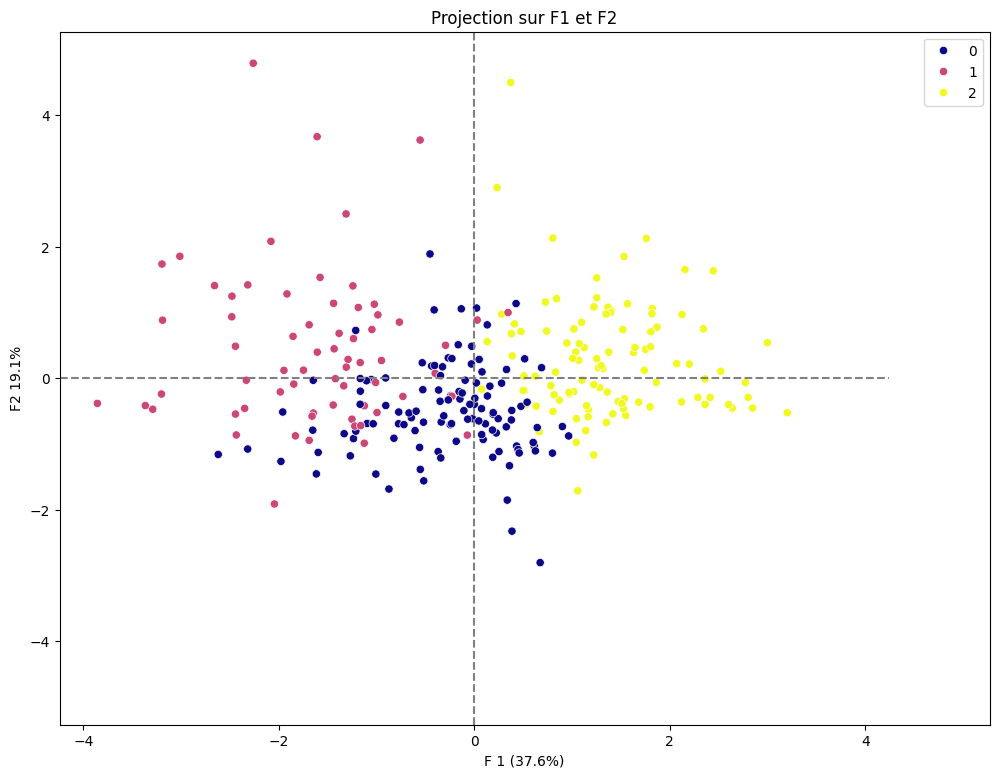

In [111]:

# projections sur F1 et F2
x_y = (0, 1)
display_factorial_planes(x_y=x_y, X_projected=X_Projected, pca=pca,clusters=clusters)


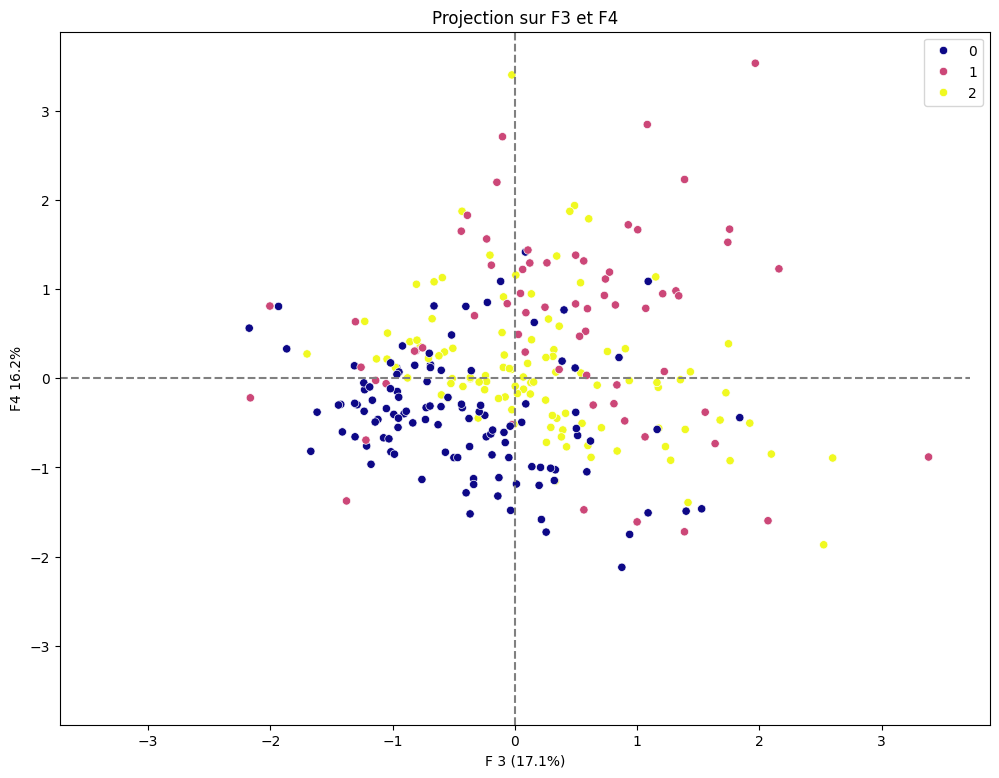

In [112]:
# projections sur F3 et F4
x_y = (2, 3)
display_factorial_planes(x_y=x_y, X_projected=X_Projected, pca=pca,clusters=clusters)

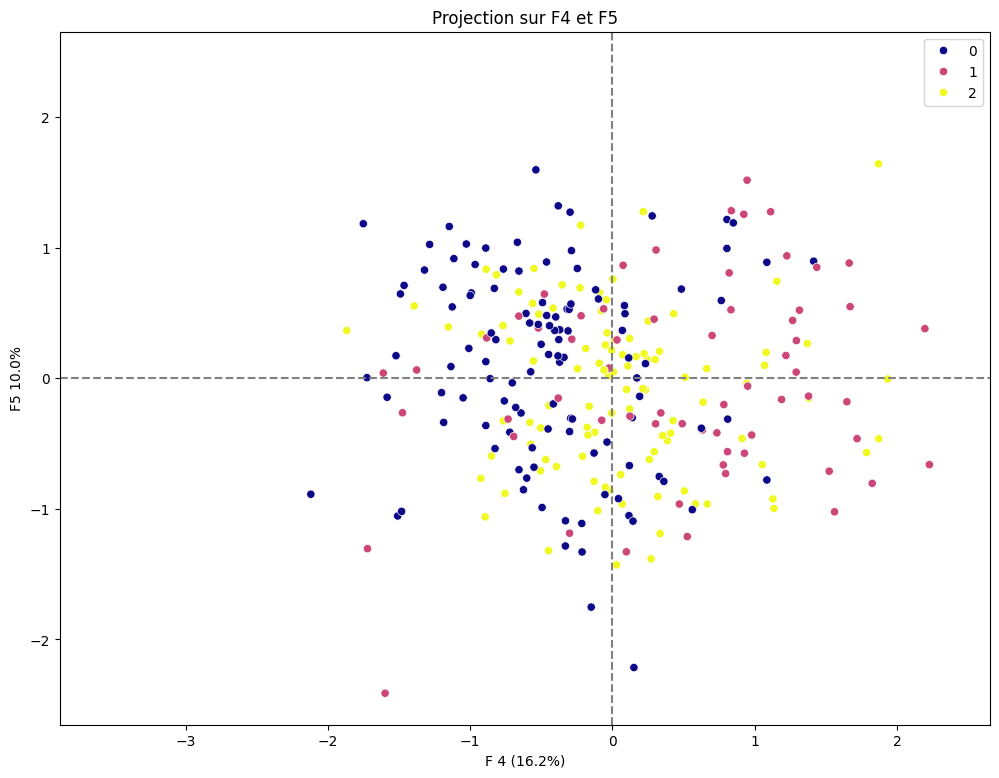

In [113]:
# projections sur F4 et F5
x_y = (3, 4)
display_factorial_planes(x_y=x_y, X_projected=X_Projected, pca=pca, clusters=clusters)

## **4.** `Conclusion`